# spatial scaffold sink token experiment

goal: test whether adding scaffold sink tokens at fixed 3d positions changes mesh generation.

background: instead of a single bos sink, place several scaffold sinks at the 8 corners of the unit cube. the idea is that each triangle could send its attention to the nearest scaffold based on position.

what this notebook does:
- generate a baseline mesh with bos as the only sink
- add 8 scaffold tokens right after bos, placed at the cube corners
- generate a mesh with the scaffolds and record attention
- measure how much attention lands on the scaffold tokens
- compare mesh quality between the baseline and scaffold runs

note: there is no retraining. scaffold tokens start as copies of the bos vector, so the model has not learned to use them by position. this run only checks whether extra sink like tokens change anything.

## imports and setup

- purpose: load the libraries and set the run environment
- method: import torch, numpy, matplotlib, scipy, the meshxl model, and tqdm, then pick the device and make the figure folder
- output: prints the device and creates the output folder

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import pearsonr
from models.mesh_xl.get_model import MeshXL
from types import SimpleNamespace
from tqdm import tqdm
import os

# use gpu if present, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# folder for saved figures
OUTPUT_DIR = 'spatial_scaffold_experiment'
# create the folder if missing
os.makedirs(OUTPUT_DIR, exist_ok=True)

/home/wkt7ne/miniforge3/envs/meshxl/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## load the meshxl model

- purpose: build the model and load the pretrained chair weights
- method: define the config, create the model, move it to the device, set eval mode, then load the checkpoint
- output: prints the vocab size and the bos, eos, and pad token ids

vocab layout: tokens 0 to 127 are coordinate values, 128 is bos, 129 is eos, 130 is pad

In [2]:
# model settings: base llm, coordinate levels, max triangle count
config = SimpleNamespace(
    llm='mesh-xl/mesh-xl-1.3b',
    n_discrete_size=128,
    n_max_triangles=800
)

# build the model from the config
model = MeshXL(config)
# move weights to the chosen device
model = model.to(device)
# eval mode turns off dropout
model.eval()

# load the pretrained chair weights
checkpoint = torch.load('ckpts/meshxl-1.3b-chair.pth', map_location=device)
# copy weights into the model, allow missing keys
model.load_state_dict(checkpoint['model'], strict=False)

print(f'model loaded')
print(f'vocab size: {model.vocab_size}')
print(f'bos token: {model.bos_token_id}')
print(f'eos token: {model.eos_token_id}')
print(f'pad token: {model.pad_token_id}')

Some weights of the model checkpoint at mesh-xl/mesh-xl-1.3b were not used when initializing OPTForCausalLM: ['tokenizer.dummpy_param', 'transformer.lm_head.weight']
- This IS expected if you are initializing OPTForCausalLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing OPTForCausalLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model loaded
vocab size: 131
bos token: 128
eos token: 129
pad token: 130


## helper functions

- purpose: define the functions reused later in the notebook
- method: tokens_to_triangles maps tokens to vertices, compute_mesh_metrics measures a mesh, apply_rotation orients the chair, plot_mesh draws the mesh
- output: no printed output, the functions are defined for later cells

In [23]:
def tokens_to_triangles(tokens, n_discrete=128):
    """
    turn a flat token list into triangle vertices
    input: 1d array of tokens 0 to 127, length is n_triangles times 9
    output: array shaped n_triangles by 3 by 3
    """
    n_tri = len(tokens) // 9  # 9 tokens make one triangle
    triangles = []  # collect triangles here
    for i in range(n_tri):
        tri_tokens = tokens[i*9:(i+1)*9]  # the 9 tokens for this triangle
        coords = (tri_tokens / (n_discrete - 1)) * 2 - 1  # map ids to the range -1 to 1
        triangles.append(coords.reshape(3, 3))  # reshape into 3 vertices of xyz
    return np.array(triangles)  # stack all triangles


def compute_mesh_metrics(triangles):
    """
    compute quality numbers for a mesh
    """
    metrics = {}  # results go here
    metrics['n_triangles'] = len(triangles)  # triangle count

    all_coords = triangles.reshape(-1, 3)  # every vertex as one list
    bbox_min = all_coords.min(axis=0)  # min corner of the bounding box
    bbox_max = all_coords.max(axis=0)  # max corner of the bounding box
    metrics['bbox_volume'] = np.prod(bbox_max - bbox_min)  # volume of the bounding box

    areas = []  # area of each triangle
    for tri in triangles:
        v0, v1, v2 = tri  # the three vertices
        area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))  # area from the cross product
        areas.append(area)
    metrics['mean_area'] = np.mean(areas)  # average area
    metrics['std_area'] = np.std(areas)  # spread of area

    centroids = triangles.mean(axis=1)  # center point of each triangle
    consecutive_dists = [np.linalg.norm(centroids[i] - centroids[i-1]) for i in range(1, len(centroids))]  # gap between successive centers
    metrics['mean_consecutive_dist'] = np.mean(consecutive_dists)  # average gap
    metrics['centroid_spread'] = np.std(centroids)  # spread of the centers

    return metrics


def apply_rotation(vertices):
    """rotate vertices so the chair sits upright"""
    # fixed 90 degree rotation around the x axis
    rotation_matrix = np.array([
        [1, 0, 0],
        [0, 0, -1],
        [0, 1, 0]
    ])
    return vertices @ rotation_matrix.T  # apply the rotation


def plot_mesh(ax, triangles, title, color='steelblue'):
    """draw a mesh as solid triangles with the chair upright"""
    n_tri = len(triangles)  # number of triangles
    verts = triangles.reshape(-1, 3)  # flatten to a list of vertices

    verts = apply_rotation(verts)  # rotate to upright

    faces = np.arange(n_tri * 3).reshape(n_tri, 3)  # group every 3 vertices into a face

    # draw the surface
    ax.plot_trisurf(
        verts[:, 0], verts[:, 1], verts[:, 2],
        triangles=faces,
        color=color,
        alpha=0.8,
        edgecolor='black',
        linewidth=0.1
    )

    ax.set_xlim(-1, 1)  # fix x range
    ax.set_ylim(-1, 1)  # fix y range
    ax.set_zlim(-1, 1)  # fix z range
    ax.view_init(elev=20, azim=-45)  # camera angle
    ax.set_axis_off()  # hide the axes
    ax.set_title(title, fontsize=14)  # title text

## baseline mesh generation

- purpose: make one mesh with bos as the only sink
- method: call the native generate method with greedy decoding, then drop triangles that contain nan
- output: prints the count of valid triangles in the baseline mesh

In [4]:
def generate_baseline(model, num_samples=1):
    """
    generate a mesh with the native method, bos as the only sink
    """
    model.eval()  # eval mode
    with torch.no_grad():  # no gradients during generation
        output = model.generate(
            data_dict=None,
            num_return_sequences=num_samples,
            generation_config=dict(do_sample=False)  # greedy decoding
        )
    return output

print('generating baseline mesh...')
baseline_output = generate_baseline(model, num_samples=1)  # run one baseline

# pull the mesh out of the output dict
baseline_mesh = baseline_output['recon_faces'][0]
# move to numpy if it is a tensor
if torch.is_tensor(baseline_mesh):
    baseline_mesh = baseline_mesh.cpu().numpy()
# mark triangles that have no nan
valid_mask = ~np.isnan(baseline_mesh).any(axis=(1,2))
# keep only the valid triangles
baseline_mesh_clean = baseline_mesh[valid_mask]

print(f'baseline: {len(baseline_mesh_clean)} valid triangles')

generating baseline mesh...
baseline: 494 valid triangles


## show the baseline mesh

- purpose: view the baseline mesh as a solid chair
- method: make a 3d axis and draw the mesh with plot_mesh at a fixed camera angle
- output: a saved png and an inline 3d plot of the baseline mesh

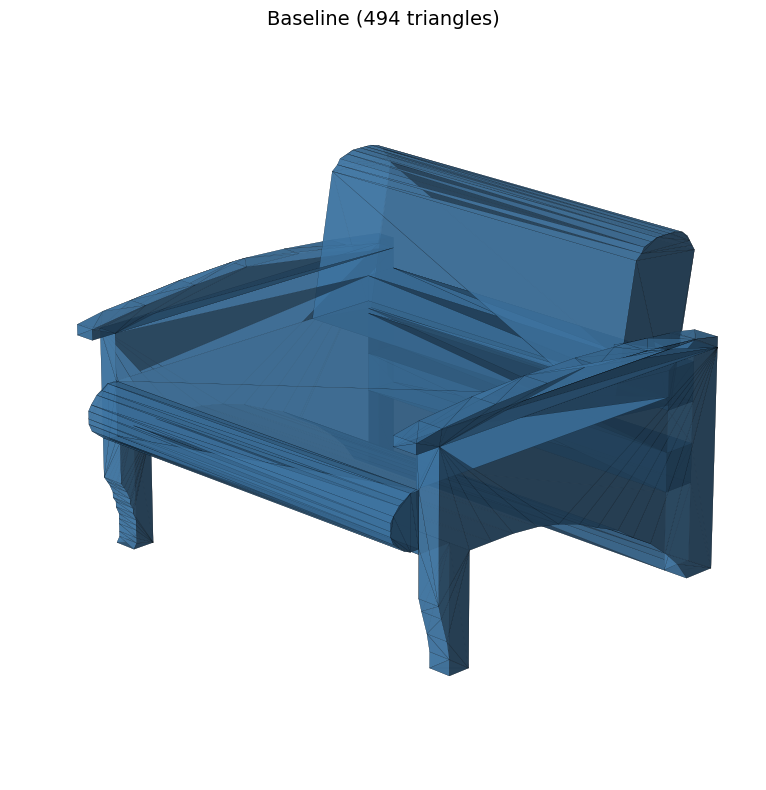

In [25]:
fig = plt.figure(figsize=(8, 8))  # new figure
ax = fig.add_subplot(111, projection='3d')  # one 3d axis
plot_mesh(ax, baseline_mesh_clean, f'baseline ({len(baseline_mesh_clean)} triangles)', color='steelblue')  # draw the mesh
plt.tight_layout()  # tidy spacing
plt.savefig(f'{OUTPUT_DIR}/baseline_mesh.png', dpi=150)  # save to file
plt.show()  # display

## save the original embeddings

- purpose: keep a copy of the token vectors before changing the model
- method: clone the embedding weight and read its shape
- output: prints the original vocab size and the embedding dimension

In [6]:
# copy the current token vectors before changing anything
original_embed = model.transformer.model.decoder.embed_tokens.weight.data.clone()
original_vocab_size = original_embed.shape[0]  # number of tokens, 131
embed_dim = original_embed.shape[1]  # vector size per token, 2048

print(f'original vocab size: {original_vocab_size}')
print(f'embedding dimension: {embed_dim}')

original vocab size: 131
embedding dimension: 2048


## define the scaffold tokens

- purpose: set up 8 extra tokens and give each a fixed 3d position
- method: assign new token ids after the current vocab and place them at the 8 corners of the unit cube
- output: prints the scaffold token ids and their positions

In [7]:
n_scaffolds = 8  # one scaffold per cube corner

# new token ids, placed right after the existing vocab
scaffold_ids = list(range(original_vocab_size, original_vocab_size + n_scaffolds))
print(f'scaffold token ids: {scaffold_ids}')

# 3d position for each scaffold, the 8 corners of the unit cube
scaffold_positions = np.array([
    [-1, -1, -1],  # 131
    [ 1, -1, -1],  # 132
    [-1,  1, -1],  # 133
    [ 1,  1, -1],  # 134
    [-1, -1,  1],  # 135
    [ 1, -1,  1],  # 136
    [-1,  1,  1],  # 137
    [ 1,  1,  1],  # 138
])
print(f'scaffold positions:')
# print each token id with its position
for i, pos in enumerate(scaffold_positions):
    print(f'  token {scaffold_ids[i]}: {pos}')

scaffold token ids: [131, 132, 133, 134, 135, 136, 137, 138]
scaffold positions:
  token 131: [-1 -1 -1]
  token 132: [ 1 -1 -1]
  token 133: [-1  1 -1]
  token 134: [ 1  1 -1]
  token 135: [-1 -1  1]
  token 136: [ 1 -1  1]
  token 137: [-1  1  1]
  token 138: [1 1 1]


## extend the embedding layer

- purpose: add room in the model for the scaffold tokens
- method: build a larger embedding table, copy the old vectors, set the scaffolds to the bos vector, then attach it to the model
- output: prints the new vocab size and confirms the scaffolds start as bos copies

why copy bos: the model already treats bos as a sink, so starting the scaffolds from the bos vector makes them sink like from the first step

In [8]:
new_vocab_size = original_vocab_size + n_scaffolds  # total tokens after adding scaffolds

# fresh lookup table with room for the extra tokens
new_embed = torch.nn.Embedding(new_vocab_size, embed_dim).to(device)

# copy the original token vectors into the new table
new_embed.weight.data[:original_vocab_size] = original_embed

# start token vector, reused for the scaffolds
bos_embedding = original_embed[model.bos_token_id]
# set each scaffold token to the start token vector
for i in range(n_scaffolds):
    new_embed.weight.data[scaffold_ids[i]] = bos_embedding.clone()

# swap the old table on the model for the new bigger one
model.transformer.model.decoder.embed_tokens = new_embed

print(f'extended vocab size: {new_vocab_size}')
print('scaffold embeddings initialized as bos copies')

extended vocab size: 139
scaffold embeddings initialized as bos copies


## generate with scaffolds and record attention

- purpose: generate a mesh with the scaffold tokens in the sequence and record attention
- method: run the model step by step with kv cache off, place bos and the 8 scaffolds first, save the attention row every 9 steps
- output: prints the valid triangle count and how many attention steps were recorded

sequence layout: bos, then s1 to s8, then the triangle tokens

In [9]:
def generate_with_scaffolds_and_capture(model, scaffold_ids, max_triangles=500, capture_every=9):
    """
    generate a mesh with scaffold tokens and record attention
    sequence layout: bos, s1, s2, ..., s8, then triangle tokens
    capture_every: record attention every n steps, 9 means once per triangle
    returns: triangle tokens and the recorded attention
    """
    model.eval()  # eval mode

    # sequence starts with bos then the 8 scaffold tokens
    generated = [model.bos_token_id] + scaffold_ids
    captured_attentions = {}  # step number to attention row

    with torch.no_grad():  # no gradients
        for step in tqdm(range(max_triangles * 9), desc='scaffold generation'):
            input_ids = torch.tensor([generated], device=device)  # current sequence as a tensor

            # forward pass with attention, kv cache off so the full matrix is returned
            outputs = model.transformer(
                input_ids=input_ids,
                output_attentions=True
            )

            # record attention on the chosen steps
            if step % capture_every == 0:
                # attention from the last layer, shape batch heads seq seq
                attn = outputs.attentions[-1]
                # average over heads, take the row from the last token
                attn_last_row = attn[0].mean(dim=0)[-1, :].cpu().numpy()
                captured_attentions[step] = attn_last_row

            # pick the next token with the highest score
            logits = outputs.logits[0, -1, :]
            next_token = logits.argmax().item()

            # stop if the model emits the end token
            if next_token == model.eos_token_id:
                print(f'eos at step {step}')
                break

            generated.append(next_token)  # add the new token and continue

    # drop bos and the scaffold tokens, keep triangle tokens only
    triangle_tokens = generated[1 + len(scaffold_ids):]
    return triangle_tokens, captured_attentions

print('generating with scaffold tokens (this takes longer due to attention capture)...')
scaffold_tokens, scaffold_attentions = generate_with_scaffolds_and_capture(
    model, scaffold_ids, max_triangles=200, capture_every=9
)

# turn the token list into triangles
scaffold_tokens = np.array(scaffold_tokens)
scaffold_mesh = tokens_to_triangles(scaffold_tokens)
# keep only triangles with no nan
valid_mask = ~np.isnan(scaffold_mesh).any(axis=(1,2))
scaffold_mesh_clean = scaffold_mesh[valid_mask]

print(f'scaffold: {len(scaffold_mesh_clean)} valid triangles')
print(f'captured attention at {len(scaffold_attentions)} steps')

generating with scaffold tokens (this takes longer due to attention capture)...


scaffold generation:  90%|████████▉ | 1612/1800 [05:04<00:35,  5.30it/s]

eos at step 1612
scaffold: 179 valid triangles
captured attention at 180 steps


## measure attention to the scaffolds

- purpose: find how attention splits between bos, the scaffolds, and the triangles
- method: for each recorded step sum the attention on position 0, on positions 1 to 8, and on positions 9 and up
- output: prints the mean attention for each group and for each scaffold

In [10]:
# attention going to each token group
bos_attentions = []  # attention on bos at position 0
scaffold_attentions_sum = []  # total attention on the 8 scaffolds
per_scaffold_attentions = [[] for _ in range(n_scaffolds)]  # attention on each scaffold
triangle_attentions = []  # attention on triangle tokens

# go through each recorded step
for step, attn in scaffold_attentions.items():
    # attn is the attention from the last token to all earlier tokens

    # position 0 is bos
    bos_attentions.append(attn[0])

    # positions 1 to 8 are the scaffolds
    scaffold_total = attn[1:9].sum()
    scaffold_attentions_sum.append(scaffold_total)

    # attention on each scaffold on its own
    for i in range(n_scaffolds):
        per_scaffold_attentions[i].append(attn[1 + i])

    # positions 9 and up are triangle tokens
    if len(attn) > 9:
        triangle_attentions.append(attn[9:].sum())
    else:
        triangle_attentions.append(0)

# turn the lists into arrays
bos_attentions = np.array(bos_attentions)
scaffold_attentions_sum = np.array(scaffold_attentions_sum)
triangle_attentions = np.array(triangle_attentions)
per_scaffold_attentions = [np.array(x) for x in per_scaffold_attentions]

print('attention distribution (mean across generation):')
print(f'  bos:       {bos_attentions.mean():.3f} ({bos_attentions.mean()*100:.1f}%)')
print(f'  scaffolds: {scaffold_attentions_sum.mean():.3f} ({scaffold_attentions_sum.mean()*100:.1f}%)')
print(f'  triangles: {triangle_attentions.mean():.3f} ({triangle_attentions.mean()*100:.1f}%)')
print(f'\nper-scaffold attention:')
for i in range(n_scaffolds):
    pos = scaffold_positions[i]
    mean_attn = per_scaffold_attentions[i].mean()
    print(f'  scaffold {scaffold_ids[i]} {pos}: {mean_attn:.4f}')

attention distribution (mean across generation):
  bos:       0.038 (3.8%)
  scaffolds: 0.298 (29.8%)
  triangles: 0.663 (66.3%)

per-scaffold attention:
  scaffold 131 [-1 -1 -1]: 0.0296
  scaffold 132 [ 1 -1 -1]: 0.0232
  scaffold 133 [-1  1 -1]: 0.0367
  scaffold 134 [ 1  1 -1]: 0.0409
  scaffold 135 [-1 -1  1]: 0.0409
  scaffold 136 [ 1 -1  1]: 0.0422
  scaffold 137 [-1  1  1]: 0.0413
  scaffold 138 [1 1 1]: 0.0435


## plot attention over generation

- purpose: show how the attention split changes during generation
- method: the left panel stacks bos, scaffolds, and triangles over the steps, the right panel shows mean attention per scaffold
- output: a saved png with the two panels

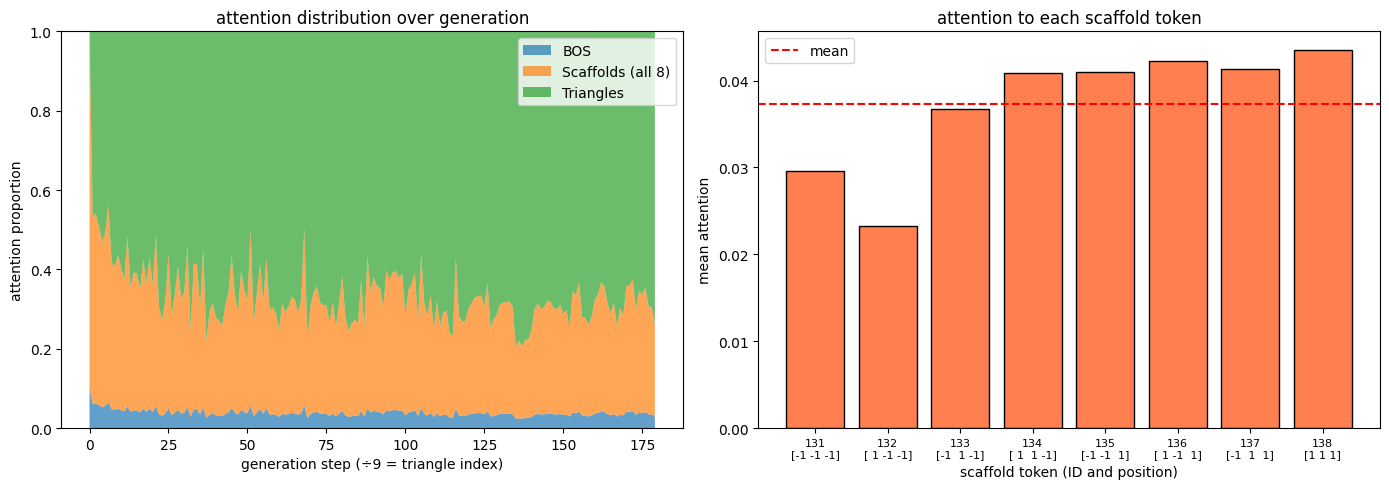

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # two panels

# left panel: attention split over generation
steps = list(scaffold_attentions.keys())
ax1 = axes[0]
# stack bos, scaffolds, and triangles as filled bands
ax1.fill_between(range(len(steps)), 0, bos_attentions, alpha=0.7, label='bos')
ax1.fill_between(range(len(steps)), bos_attentions, bos_attentions + scaffold_attentions_sum,
                 alpha=0.7, label='scaffolds all 8')
ax1.fill_between(range(len(steps)), bos_attentions + scaffold_attentions_sum,
                 bos_attentions + scaffold_attentions_sum + triangle_attentions,
                 alpha=0.7, label='triangles')
ax1.set_xlabel('generation step, divide by 9 for triangle index')
ax1.set_ylabel('attention proportion')
ax1.set_title('attention distribution over generation')
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1)

# right panel: mean attention per scaffold
ax2 = axes[1]
scaffold_means = [arr.mean() for arr in per_scaffold_attentions]  # average per scaffold
scaffold_labels = [f'{scaffold_ids[i]}\n{scaffold_positions[i]}' for i in range(n_scaffolds)]  # id and position labels
bars = ax2.bar(range(n_scaffolds), scaffold_means, color='coral', edgecolor='black')
ax2.set_xticks(range(n_scaffolds))
ax2.set_xticklabels(scaffold_labels, fontsize=8)
ax2.set_xlabel('scaffold token, id and position')
ax2.set_ylabel('mean attention')
ax2.set_title('attention to each scaffold token')
ax2.axhline(np.mean(scaffold_means), color='red', linestyle='--', label='mean')  # line at the overall mean
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/scaffold_attention_analysis.png', dpi=150)
plt.show()

## attention heatmap

- purpose: show which token positions receive attention across steps
- method: stack the attention rows into a matrix over the first 30 positions and draw it as a heatmap
- output: a saved png heatmap with bos and the scaffold block marked

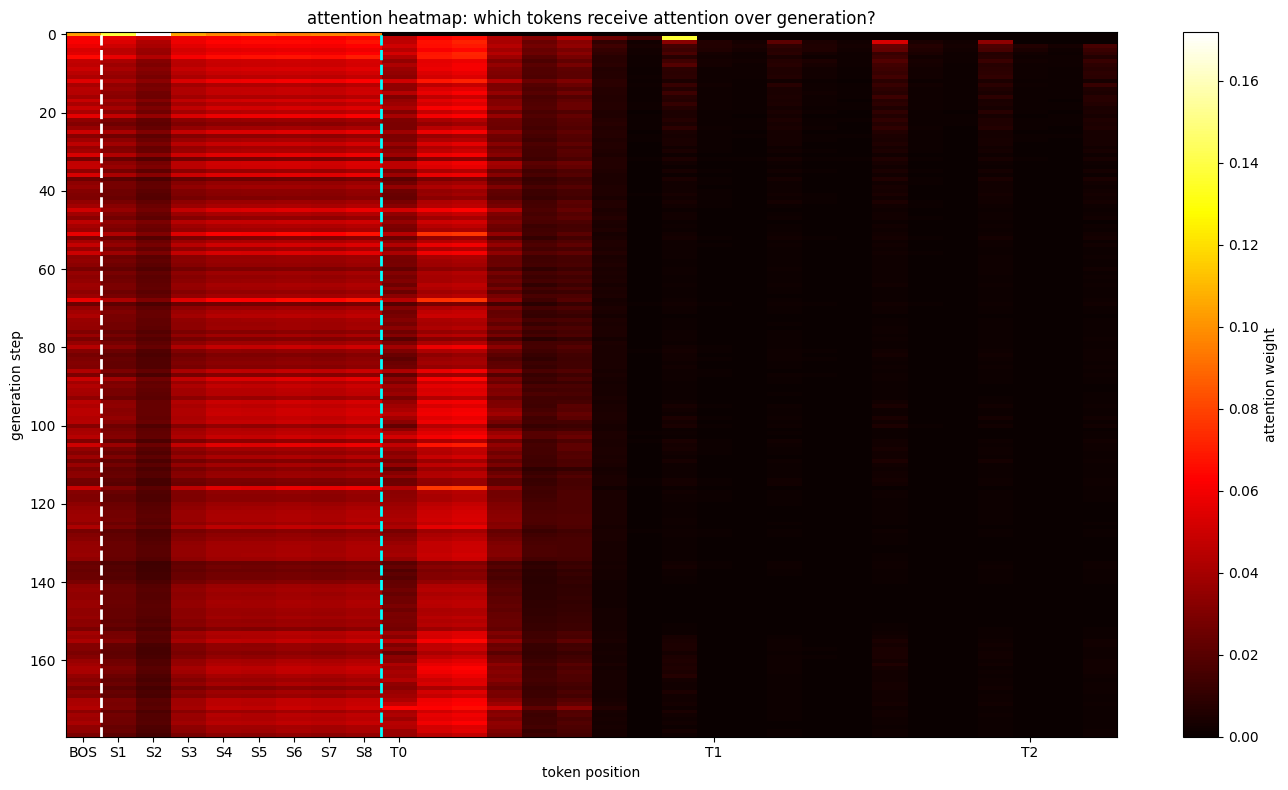

In [12]:
# show the first 30 positions: bos, 8 scaffolds, then the first couple of triangles
n_positions = 30

# build a matrix of attention rows, one row per recorded step
steps_sorted = sorted(scaffold_attentions.keys())
attn_matrix = []
for step in steps_sorted:
    attn = scaffold_attentions[step]
    # pad short rows or cut long rows to a fixed width
    if len(attn) >= n_positions:
        attn_matrix.append(attn[:n_positions])
    else:
        padded = np.zeros(n_positions)
        padded[:len(attn)] = attn
        attn_matrix.append(padded)

attn_matrix = np.array(attn_matrix)

# draw the heatmap
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(attn_matrix, aspect='auto', cmap='hot')

ax.set_xlabel('token position')
ax.set_ylabel('generation step')
ax.set_title('attention heatmap over generation')

# mark the bos column and the end of the scaffold block
ax.axvline(0.5, color='white', linestyle='--', linewidth=2, label='bos')
ax.axvline(8.5, color='cyan', linestyle='--', linewidth=2, label='scaffolds end')

# label the important columns
xticks = [0] + list(range(1, 9)) + [9, 18, 27]
xticklabels = ['bos'] + [f's{i+1}' for i in range(8)] + ['t0', 't1', 't2']
ax.set_xticks(xticks[:len(xticklabels)])
ax.set_xticklabels(xticklabels[:len(xticks)])

plt.colorbar(im, label='attention weight')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/attention_heatmap.png', dpi=150)
plt.show()

## compare mesh quality

- purpose: compare the baseline and scaffold meshes by number
- method: compute the metrics for both meshes and print the percent change
- output: a printed table of metrics for baseline and scaffold

In [13]:
# compute the metrics for both meshes
baseline_metrics = compute_mesh_metrics(baseline_mesh_clean)
scaffold_metrics = compute_mesh_metrics(scaffold_mesh_clean)

print('mesh quality comparison:')
print(f'{"metric":<25} {"baseline":>12} {"scaffold":>12}')
# print each metric with the percent change
for key in baseline_metrics:
    b_val = baseline_metrics[key]
    s_val = scaffold_metrics[key]
    diff_pct = (s_val - b_val) / b_val * 100 if b_val != 0 else 0
    print(f'{key:<25} {b_val:>12.4f} {s_val:>12.4f} ({diff_pct:+.1f}%)')

mesh quality comparison:
metric                        baseline     scaffold
n_triangles                   494.0000     179.0000 (-63.8%)
bbox_volume                     7.0756       6.2362 (-11.9%)
mean_area                       0.0544       0.0972 (+78.6%)
std_area                        0.1261       0.2683 (+112.8%)
mean_consecutive_dist           0.5799       0.5380 (-7.2%)
centroid_spread                 0.6850       0.7107 (+3.8%)


## show both meshes side by side

- purpose: compare the two meshes by eye
- method: draw the baseline and the scaffold mesh on two 3d axes at the same angle
- output: a saved png with the two meshes

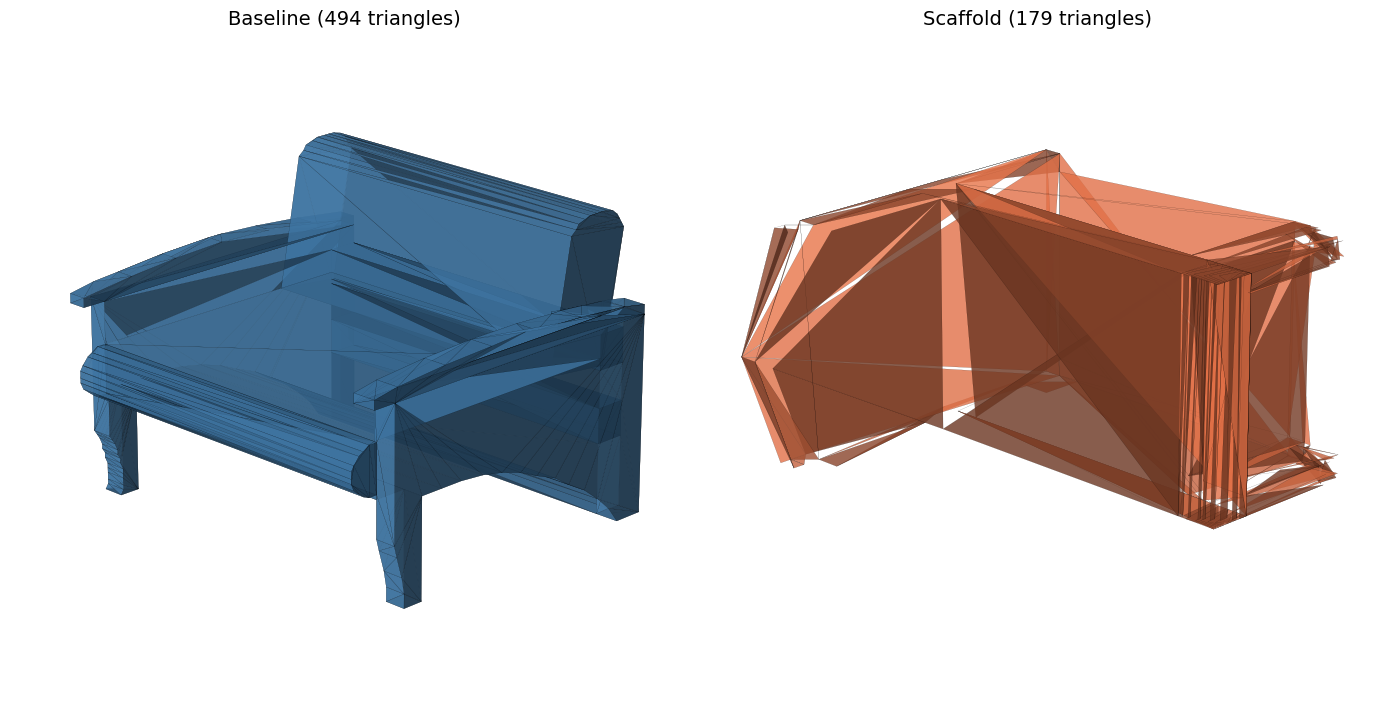

In [27]:
fig = plt.figure(figsize=(14, 7))  # wide figure for two views

ax1 = fig.add_subplot(121, projection='3d')  # left 3d axis
plot_mesh(ax1, baseline_mesh_clean, f'baseline ({len(baseline_mesh_clean)} triangles)', color='steelblue')

ax2 = fig.add_subplot(122, projection='3d')  # right 3d axis
plot_mesh(ax2, scaffold_mesh_clean, f'scaffold ({len(scaffold_mesh_clean)} triangles)', color='coral')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/baseline_vs_scaffold.png', dpi=150)
plt.show()

## compare spatial coherence

- purpose: check whether the scaffolds change how far apart successive triangles are
- method: measure the gap between each triangle center and the one before it for both meshes
- output: a saved png with a line plot and a histogram of the gaps

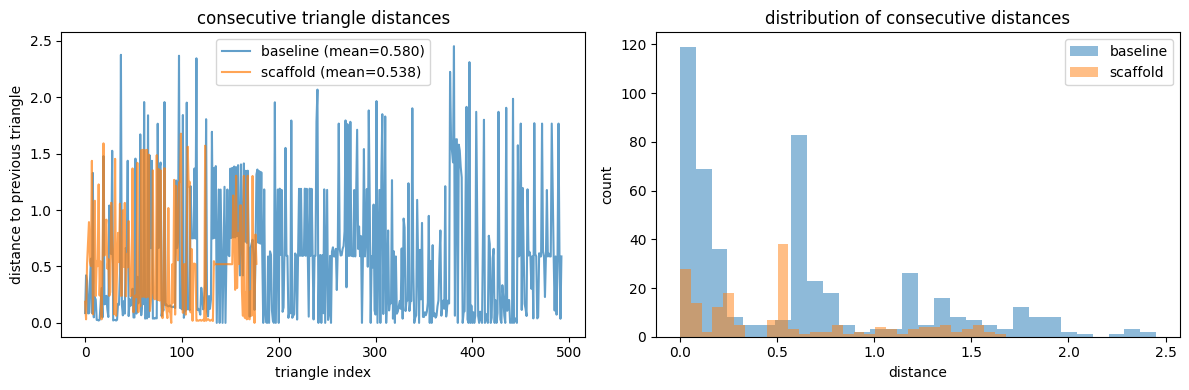

In [15]:
def get_consecutive_distances(triangles):
    # distance between each triangle center and the one before it
    centroids = triangles.mean(axis=1)
    return [np.linalg.norm(centroids[i] - centroids[i-1]) for i in range(1, len(centroids))]

baseline_dists = get_consecutive_distances(baseline_mesh_clean)  # gaps for the baseline
scaffold_dists = get_consecutive_distances(scaffold_mesh_clean)  # gaps for the scaffold run

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # two panels

# left panel: gap over the sequence
axes[0].plot(baseline_dists, alpha=0.7, label=f'baseline (mean={np.mean(baseline_dists):.3f})')
axes[0].plot(scaffold_dists, alpha=0.7, label=f'scaffold (mean={np.mean(scaffold_dists):.3f})')
axes[0].set_xlabel('triangle index')
axes[0].set_ylabel('distance to previous triangle')
axes[0].set_title('consecutive triangle distances')
axes[0].legend()

# right panel: distribution of the gaps
axes[1].hist(baseline_dists, bins=30, alpha=0.5, label='baseline')
axes[1].hist(scaffold_dists, bins=30, alpha=0.5, label='scaffold')
axes[1].set_xlabel('distance')
axes[1].set_ylabel('count')
axes[1].set_title('distribution of consecutive distances')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/spatial_coherence.png', dpi=150)
plt.show()